1. **ANALYSE DU DATASET**

ANALYSE DU DATASET PROFESSEUR

✅ Dataset trouvé : /kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images

📁 STRUCTURE DU DATASET
------------------------------------------------------------
📁 facesDataset/ (30571 items)
  📄 0000000.png (0.02 MB)
  📄 0000001.png (0.02 MB)
  📄 0000002.png (0.02 MB)
  📄 0000003.png (0.03 MB)
  📄 0000004.png (0.03 MB)
  📄 0000005.png (0.02 MB)
  📄 0000006.png (0.03 MB)
  📄 0000007.png (0.02 MB)
  📄 0000008.png (0.02 MB)
  📄 0000009.png (0.03 MB)
  📄 0000010.png (0.02 MB)
  📄 0000011.png (0.02 MB)
  📄 0000012.png (0.03 MB)
  📄 0000013.png (0.03 MB)
  📄 0000014.png (0.03 MB)
  📄 0000015.png (0.03 MB)
  📄 0000016.png (0.02 MB)
  📄 0000017.png (0.03 MB)
  📄 0000018.png (0.02 MB)
  📄 0000019.png (0.03 MB)
  ... et 30551 autres items
📁 facesDataset_masked/ (24678 items)
  📄 0000000_surgical_green.png (0.03 MB)
  📄 0000001_inpaint.png (0.03 MB)
  📄 0000002_empty.png (0.02 MB)
  📄 0000003_surgical_green.png (0.03 MB)
  📄 0000004_cloth.png (0.03 MB)
  📄 0000

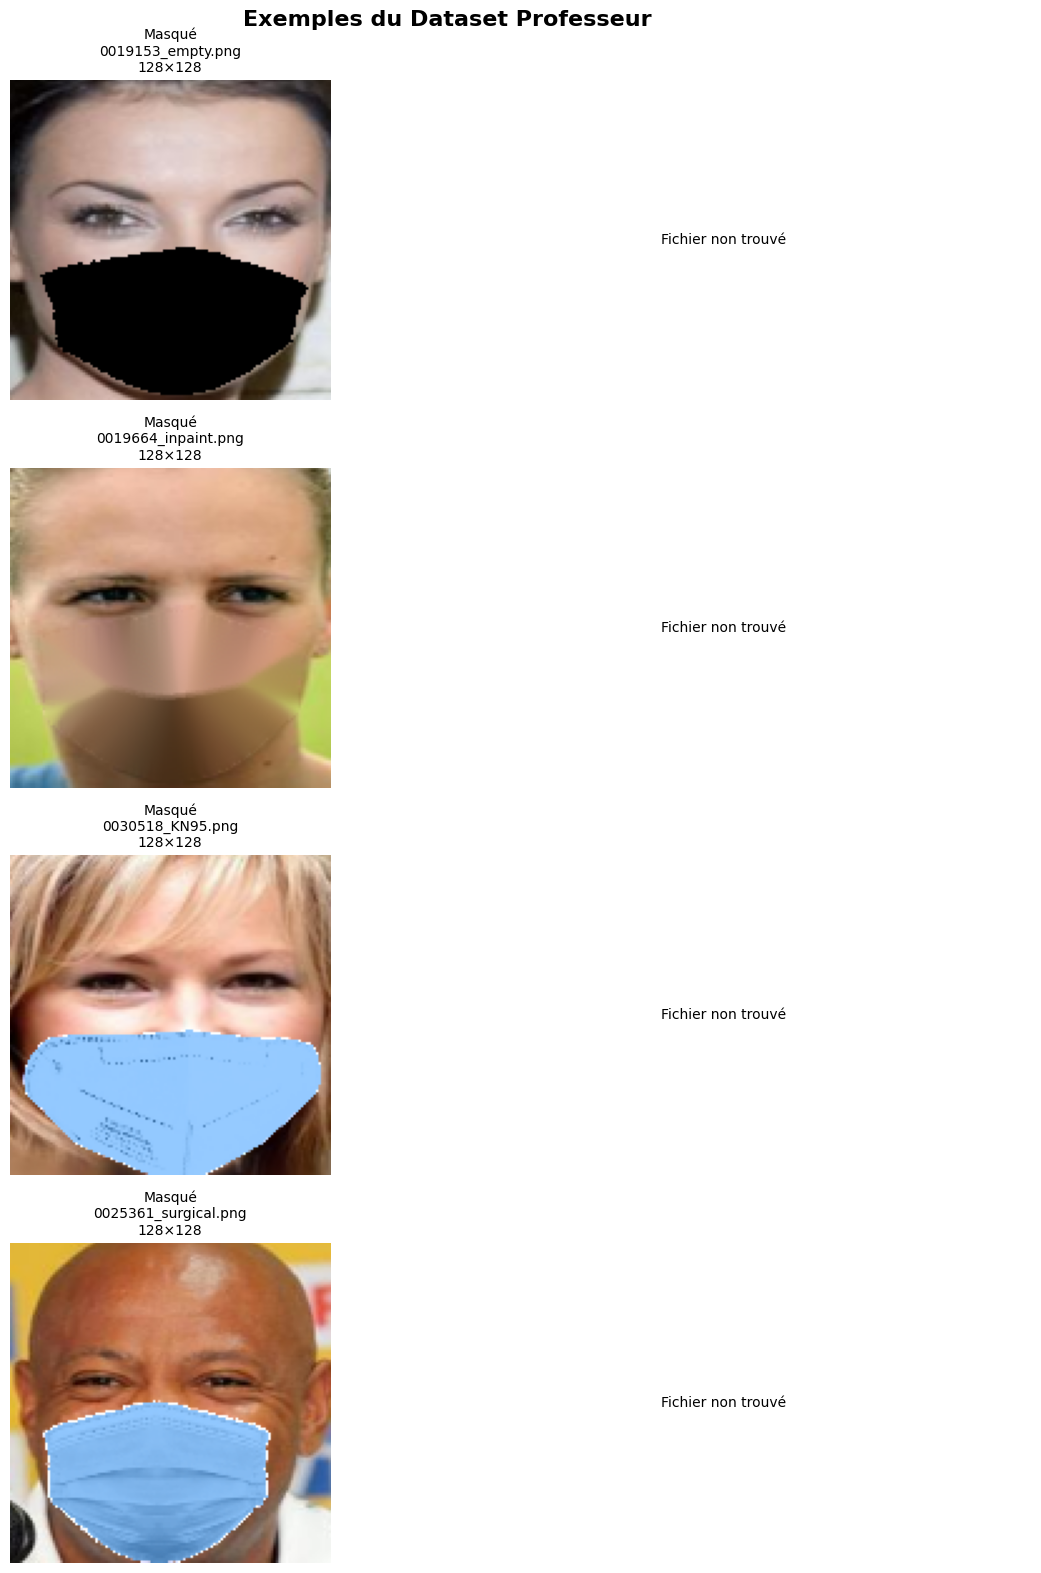

✅ Visualisation sauvegardée et affichée


📊 RECOMMANDATIONS

✅ Dataset analysé : 24678 paires détectées

⚠️  CORRECT mais peut être amélioré
   → Suffisant pour un premier entraînement
   → Possibilité d'ajouter CelebA si résultats < 27 PSNR

✅ DÉCISION : Commencer avec ce dataset
              Préparer CelebA en parallèle (optionnel)


📐 VÉRIFICATION DES DIMENSIONS REQUISES
------------------------------------------------------------
Dimensions actuelles :
  Masqué     : 128×128
  Non-masqué : 128×128

Dimensions requises :
  Input  : 32×32
  Target : 128×128

⚠️  RESIZE NÉCESSAIRE
   → Créer script de preprocessing
   → Voir 'preprocessing_script.py'

ANALYSE TERMINÉE

📝 Prochaines étapes :
1. ✅ Dataset analysé
2. Lire JDSR-GAN + Cheng EFBPGAN (2h)
3. Télécharger codes GitHub
4. Créer DataLoader PyTorch
5. Commencer l'implémentation !

💡 TIP KAGGLE :
   Activez GPU : Settings → Accelerator → GPU P100
   Cela sera nécessaire pour l'entraînement !


In [1]:

import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("="*60)
print("ANALYSE DU DATASET PROFESSEUR")
print("="*60)

# ============================================
# CONFIGURATION KAGGLE
# ============================================
DATASET_PATH = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images"

if not os.path.exists(DATASET_PATH):
    print(f"\n❌ Dataset introuvable : {DATASET_PATH}")
    print("\n💡 Vérifiez que vous avez bien ajouté le dataset dans votre notebook")
    print("   Settings → Add Data → Search 'masked celebahq cropped'")
    exit(1)

print(f"\n✅ Dataset trouvé : {DATASET_PATH}\n")

# ============================================
# 1. STRUCTURE DU DATASET
# ============================================
print("📁 STRUCTURE DU DATASET")
print("-" * 60)

def analyze_structure(path, level=0, max_level=2):
    """Analyse récursive de la structure"""
    if level > max_level:
        return
    
    try:
        items = sorted(os.listdir(path))
        for item in items[:20]:  # Afficher plus d'items
            item_path = os.path.join(path, item)
            indent = "  " * level
            
            if os.path.isdir(item_path):
                try:
                    num_files = len(os.listdir(item_path))
                    print(f"{indent}📁 {item}/ ({num_files} items)")
                    if level < max_level:
                        analyze_structure(item_path, level + 1, max_level)
                except:
                    print(f"{indent}📁 {item}/ (inaccessible)")
            else:
                size_mb = os.path.getsize(item_path) / (1024 * 1024)
                print(f"{indent}📄 {item} ({size_mb:.2f} MB)")
        
        if len(items) > 20:
            print(f"{indent}... et {len(items) - 20} autres items")
    except Exception as e:
        print(f"Erreur : {e}")

analyze_structure(DATASET_PATH)

# ============================================
# 2. TROUVER LES DOSSIERS IMAGES
# ============================================
print("\n\n🔍 RECHERCHE DES DOSSIERS D'IMAGES")
print("-" * 60)

def find_image_dirs(root_path):
    """Trouve tous les dossiers contenant des images"""
    image_dirs = {}
    
    for dirpath, dirnames, filenames in os.walk(root_path):
        # Compter les images dans ce dossier
        images = [f for f in filenames 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            rel_path = os.path.relpath(dirpath, root_path)
            image_dirs[rel_path] = len(images)
    
    return image_dirs

image_dirs = find_image_dirs(DATASET_PATH)

print("\nDossiers trouvés :")
for dir_name, count in sorted(image_dirs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {dir_name:50s} : {count:6d} images")

# ============================================
# 3. IDENTIFIER MASQUÉ vs NON-MASQUÉ
# ============================================
print("\n\n🎭 IDENTIFICATION MASQUÉ / NON-MASQUÉ")
print("-" * 60)

masked_dir = None
unmasked_dir = None

# Chercher avec différents patterns possibles
for dir_name in image_dirs.keys():
    dir_lower = dir_name.lower()
    
    # Patterns pour masqué
    if any(keyword in dir_lower for keyword in ['mask', 'masked', 'with_mask', 'withmask']):
        if not any(kw in dir_lower for kw in ['unmask', 'unmasked', 'without', 'clean']):
            masked_dir = dir_name
            print(f"✅ Trouvé MASQUÉ : {dir_name}")
    
    # Patterns pour non-masqué  
    if any(keyword in dir_lower for keyword in ['unmask', 'unmasked', 'without', 'clean', 'original', 'no_mask', 'nomask']):
        unmasked_dir = dir_name
        print(f"✅ Trouvé NON-MASQUÉ : {dir_name}")

# Si pas trouvé automatiquement, essayer des chemins probables
if not masked_dir or not unmasked_dir:
    print("\n⚠️  Détection automatique échouée, test des chemins standards...")
    
    possible_paths = [
        ('facesDataset_masked', 'facesDataset'),
        ('masked', 'unmasked'),
        ('with_mask', 'without_mask'),
        ('.', '.')  # Parfois les images sont directement dans le dossier root
    ]
    
    for mask_path, unmask_path in possible_paths:
        test_masked = os.path.join(DATASET_PATH, mask_path) if mask_path != '.' else DATASET_PATH
        test_unmasked = os.path.join(DATASET_PATH, unmask_path) if unmask_path != '.' else DATASET_PATH
        
        if os.path.exists(test_masked) and os.path.exists(test_unmasked):
            masked_files = [f for f in os.listdir(test_masked) if f.endswith(('.png', '.jpg'))]
            unmasked_files = [f for f in os.listdir(test_unmasked) if f.endswith(('.png', '.jpg'))]
            
            if masked_files and unmasked_files:
                masked_dir = mask_path
                unmasked_dir = unmask_path
                print(f"✅ Détecté : {mask_path} / {unmask_path}")
                break

if masked_dir:
    print(f"\n✅ Dossier MASQUÉ     : {masked_dir}")
    print(f"   → {image_dirs.get(masked_dir, 0)} images")
else:
    print(f"\n❌ Dossier MASQUÉ non trouvé")

if unmasked_dir:
    print(f"\n✅ Dossier NON-MASQUÉ : {unmasked_dir}")
    print(f"   → {image_dirs.get(unmasked_dir, 0)} images")
else:
    print(f"\n❌ Dossier NON-MASQUÉ non trouvé")

if not masked_dir or not unmasked_dir:
    print("\n⚠️  ATTENTION : Vérifiez manuellement la structure")
    print("Listez les dossiers disponibles ci-dessus")

# ============================================
# 4. ANALYSE DES DIMENSIONS
# ============================================
print("\n\n📐 ANALYSE DES DIMENSIONS")
print("-" * 60)

def analyze_dimensions(dir_path, sample_size=100):
    """Analyse les dimensions d'un échantillon"""
    if not dir_path:
        return None
        
    full_path = os.path.join(DATASET_PATH, dir_path) if dir_path != '.' else DATASET_PATH
    
    if not os.path.exists(full_path):
        return None
    
    images = [f for f in os.listdir(full_path) 
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not images:
        return None
    
    # Échantillonner
    sample = np.random.choice(images, min(sample_size, len(images)), replace=False)
    
    dimensions = []
    for img_name in sample:
        try:
            img_path = os.path.join(full_path, img_name)
            with Image.open(img_path) as img:
                dimensions.append(img.size)  # (width, height)
        except Exception as e:
            continue
    
    return dimensions

dims_masked = None
dims_unmasked = None

if masked_dir:
    print(f"\nImages MASQUÉES :")
    dims_masked = analyze_dimensions(masked_dir)
    if dims_masked:
        dim_counts = Counter(dims_masked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_masked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

if unmasked_dir:
    print(f"\nImages NON-MASQUÉES :")
    dims_unmasked = analyze_dimensions(unmasked_dir)
    if dims_unmasked:
        dim_counts = Counter(dims_unmasked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_unmasked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

# ============================================
# 5. VÉRIFIER SI PAIRES
# ============================================
print("\n\n🔗 VÉRIFICATION DES PAIRES")
print("-" * 60)

masked_files = []
unmasked_files = []

if masked_dir and unmasked_dir:
    masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
    unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
    
    masked_files = sorted([f for f in os.listdir(masked_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    unmasked_files = sorted([f for f in os.listdir(unmasked_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"\nNombre de fichiers masqués    : {len(masked_files)}")
    print(f"Nombre de fichiers non-masqués : {len(unmasked_files)}")
    
    # Comparer noms
    if len(masked_files) == len(unmasked_files):
        print("✅ Même nombre de fichiers")
        
        # Vérifier si noms correspondent
        if masked_files[:10] == unmasked_files[:10]:
            print("✅ Les noms de fichiers correspondent")
            print("\nExemples de paires :")
            for i in range(min(5, len(masked_files))):
                print(f"  {i+1}. {masked_files[i]}")
        else:
            print("⚠️  Les noms de fichiers NE correspondent PAS")
            print("\nMasqué (premiers 3)   :", masked_files[:3])
            print("Non-masqué (premiers 3):", unmasked_files[:3])
    else:
        print("⚠️  Nombre de fichiers DIFFÉRENT")
        diff = abs(len(masked_files) - len(unmasked_files))
        print(f"   Différence : {diff} fichiers")

# ============================================
# 6. VISUALISATION D'EXEMPLES  
# ============================================
print("\n\n📸 GÉNÉRATION DE VISUALISATIONS")
print("-" * 60)

if masked_dir and unmasked_dir and masked_files:
    try:
        masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
        unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
        
        # Prendre 4 exemples aléatoires
        sample_files = np.random.choice(masked_files, min(4, len(masked_files)), replace=False)
        
        fig, axes = plt.subplots(4, 2, figsize=(12, 16))
        fig.suptitle("Exemples du Dataset Professeur", fontsize=16, fontweight='bold')
        
        for i, filename in enumerate(sample_files):
            # Image masquée
            masked_img_path = os.path.join(masked_path, filename)
            try:
                masked_img = Image.open(masked_img_path)
                axes[i, 0].imshow(masked_img)
                axes[i, 0].set_title(f"Masqué\n{filename[:30]}\n{masked_img.size[0]}×{masked_img.size[1]}", 
                                    fontsize=10)
                axes[i, 0].axis('off')
            except Exception as e:
                axes[i, 0].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                              ha='center', va='center', fontsize=8)
                axes[i, 0].axis('off')
            
            # Image non-masquée
            unmasked_img_path = os.path.join(unmasked_path, filename)
            if os.path.exists(unmasked_img_path):
                try:
                    unmasked_img = Image.open(unmasked_img_path)
                    axes[i, 1].imshow(unmasked_img)
                    axes[i, 1].set_title(f"Non-masqué\n{filename[:30]}\n{unmasked_img.size[0]}×{unmasked_img.size[1]}", 
                                        fontsize=10)
                    axes[i, 1].axis('off')
                except Exception as e:
                    axes[i, 1].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                                  ha='center', va='center', fontsize=8)
                    axes[i, 1].axis('off')
            else:
                axes[i, 1].text(0.5, 0.5, "Fichier non trouvé", 
                              ha='center', va='center')
                axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig("dataset_prof_examples.png", dpi=150, bbox_inches='tight')
        plt.show()  # Afficher dans Kaggle
        print("✅ Visualisation sauvegardée et affichée")
        
    except Exception as e:
        print(f"❌ Erreur lors de la visualisation : {e}")
else:
    print("⚠️  Impossible de créer la visualisation")
    print("   Vérifiez que les dossiers sont correctement identifiés")

# ============================================
# 7. RECOMMANDATIONS
# ============================================
print("\n\n" + "="*60)
print("📊 RECOMMANDATIONS")
print("="*60)

total_pairs = min(len(masked_files), len(unmasked_files)) if masked_files and unmasked_files else 0

print(f"\n✅ Dataset analysé : {total_pairs} paires détectées")

if total_pairs >= 25000:
    print("\n🎉 EXCELLENT ! Dataset très large")
    print("   → Suffisant pour entraînement complet")
    print("   → PAS besoin de combiner avec d'autres datasets")
    print("\n✅ DÉCISION : Utiliser ce dataset tel quel")
    
elif total_pairs >= 15000:
    print("\n⚠️  CORRECT mais peut être amélioré")
    print("   → Suffisant pour un premier entraînement")
    print("   → Possibilité d'ajouter CelebA si résultats < 27 PSNR")
    print("\n✅ DÉCISION : Commencer avec ce dataset")
    print("              Préparer CelebA en parallèle (optionnel)")
    
elif total_pairs >= 5000:
    print("\n⚠️  PETIT - Combinaison recommandée")
    print("   → Risque d'overfitting")
    print("   → Recommandé : Ajouter 15-20k images de CelebA")
    print("\n✅ DÉCISION : Combiner avec CelebA")
    print(f"              Objectif : {total_pairs} + 15000 = ~{total_pairs + 15000} paires")
    
else:
    print("\n❌ TRÈS PETIT ou INTROUVABLE")
    if total_pairs == 0:
        print("   → Vérifiez la structure du dataset")
        print("   → Assurez-vous d'avoir ajouté le bon dataset dans Kaggle")
    else:
        print("   → Impossible d'entraîner un GAN avec < 5000 images")
        print("   → DOIT combiner avec CelebA")

# ============================================
# 8. VÉRIFIER DIMENSIONS REQUISES
# ============================================
if dims_masked and dims_unmasked:
    most_common_masked = Counter(dims_masked).most_common(1)[0][0]
    most_common_unmasked = Counter(dims_unmasked).most_common(1)[0][0]
    
    print(f"\n\n📐 VÉRIFICATION DES DIMENSIONS REQUISES")
    print("-" * 60)
    print(f"Dimensions actuelles :")
    print(f"  Masqué     : {most_common_masked[0]}×{most_common_masked[1]}")
    print(f"  Non-masqué : {most_common_unmasked[0]}×{most_common_unmasked[1]}")
    
    print(f"\nDimensions requises :")
    print(f"  Input  : 32×32")
    print(f"  Target : 128×128")
    
    need_resize = (most_common_masked != (32, 32) or 
                   most_common_unmasked != (128, 128))
    
    if need_resize:
        print(f"\n⚠️  RESIZE NÉCESSAIRE")
        print(f"   → Créer script de preprocessing")
        print(f"   → Voir 'preprocessing_script.py'")
    else:
        print(f"\n✅ DIMENSIONS CORRECTES")
        print(f"   → Dataset prêt à l'emploi !")

print("\n" + "="*60)
print("ANALYSE TERMINÉE")
print("="*60)

if total_pairs > 0:
    print("\n📝 Prochaines étapes :")
    print("1. ✅ Dataset analysé")
    print("2. Lire JDSR-GAN + Cheng EFBPGAN (2h)")
    print("3. Télécharger codes GitHub")
    print("4. Créer DataLoader PyTorch")
    print("5. Commencer l'implémentation !")
else:
    print("\n⚠️  Problème détecté :")
    print("1. Vérifiez que le dataset est bien ajouté dans Kaggle")
    print("2. Regardez la structure affichée ci-dessus")
    print("3. Ajustez les chemins si nécessaire")
    
print("\n💡 TIP KAGGLE :")
print("   Activez GPU : Settings → Accelerator → GPU P100")
print("   Cela sera nécessaire pour l'entraînement !")


**PREPROCESSING DATASET - Créer les bonnes dimensions32×32 masqué → 128×128 non-masqué**

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil

print("="*60)
print("PREPROCESSING DATASET")
print("="*60)

# ============================================
# CONFIGURATION
# ============================================
INPUT_MASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset_masked"
INPUT_UNMASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset"

OUTPUT_DIR = "/kaggle/working/dataset_processed"

# Création dossiers
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "input_32"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "target_128"), exist_ok=True)

print(f"\n✅ Dossiers créés dans : {OUTPUT_DIR}\n")

# ============================================
# CRÉER LES PAIRES
# ============================================
print("🔍 Identification des paires...")

masked_files = sorted([f for f in os.listdir(INPUT_MASKED) if f.endswith('.png')])
pairs = []

for masked_file in masked_files:
    num_str = masked_file[:7]
    unmasked_file = f"{num_str}.png"
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    if os.path.exists(unmasked_path):
        pairs.append((masked_file, unmasked_file))

print(f"✅ {len(pairs)} paires trouvées\n")

# ============================================
# SPLIT TRAIN/VAL/TEST
# ============================================
np.random.seed(42)
np.random.shuffle(pairs)

n_train = int(len(pairs) * 0.8)
n_val = int(len(pairs) * 0.1)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print(f"📊 Split :")
print(f"  Train : {len(train_pairs)}")
print(f"  Val   : {len(val_pairs)}")
print(f"  Test  : {len(test_pairs)}\n")

# ============================================
# FONCTION DE TRAITEMENT
# ============================================
def process_pair(masked_file, unmasked_file, split_name, idx):

    masked_path = os.path.join(INPUT_MASKED, masked_file)
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    masked_img = cv2.imread(masked_path)
    unmasked_img = cv2.imread(unmasked_path)

    if masked_img is None:
        print(f"❌ Erreur lecture : {masked_path}")
        return False

    if unmasked_img is None:
        print(f"❌ Erreur lecture : {unmasked_path}")
        return False

    # Resize INPUT 32x32
    masked_32 = cv2.resize(masked_img, (32, 32), interpolation=cv2.INTER_CUBIC)

    # TARGET reste 128x128
    unmasked_128 = unmasked_img

    input_path = os.path.join(OUTPUT_DIR, split_name, "input_32", f"{idx:06d}.png")
    target_path = os.path.join(OUTPUT_DIR, split_name, "target_128", f"{idx:06d}.png")

    # Vérifier que l'écriture fonctionne
    ok1 = cv2.imwrite(input_path, masked_32)
    ok2 = cv2.imwrite(target_path, unmasked_128)

    if not ok1 or not ok2:
        print(f"❌ Erreur sauvegarde : {idx}")
        return False

    return True

# ============================================
# TRAITEMENT SPLITS
# ============================================
def process_split(pairs, split_name):

    print(f"\n🔄 Processing {split_name.upper()}...")
    success = 0

    for idx, (masked_file, unmasked_file) in enumerate(tqdm(pairs)):
        if process_pair(masked_file, unmasked_file, split_name, idx):
            success += 1

    print(f"✅ {split_name}: {success}/{len(pairs)} sauvegardées")
    return success


train_success = process_split(train_pairs, "train")
val_success = process_split(val_pairs, "val")
test_success = process_split(test_pairs, "test")

# ============================================
# RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("✅ PREPROCESSING TERMINÉ")
print("="*60)

total = train_success + val_success + test_success
print(f"\n📊 TOTAL sauvegardé : {total} images")

# ============================================
# VÉRIFICATION
# ============================================
if train_success > 0:
    example_input = cv2.imread(os.path.join(OUTPUT_DIR, "train/input_32/000000.png"))
    example_target = cv2.imread(os.path.join(OUTPUT_DIR, "train/target_128/000000.png"))

    print("\n🔎 Vérification dimensions :")
    print("Input  :", example_input.shape)
    print("Target :", example_target.shape)

# ============================================
# ZIP FINAL
# ============================================
print("\n📦 Compression en cours...")

zip_path = shutil.make_archive(
    os.path.join("/kaggle/working", "dataset_processed"),
    'zip',
    OUTPUT_DIR
)

print(f"✅ ZIP créé : {zip_path}")
print("Télécharge-le depuis l’onglet OUTPUT de Kaggle.")

PREPROCESSING DATASET

✅ Dossiers créés dans : /kaggle/working/dataset_processed

🔍 Identification des paires...
✅ 24678 paires trouvées

📊 Split :
  Train : 19742
  Val   : 2467
  Test  : 2469


🔄 Processing TRAIN...


100%|██████████| 19742/19742 [09:49<00:00, 33.51it/s]


✅ train: 19742/19742 sauvegardées

🔄 Processing VAL...


100%|██████████| 2467/2467 [01:12<00:00, 33.81it/s]


✅ val: 2467/2467 sauvegardées

🔄 Processing TEST...


100%|██████████| 2469/2469 [01:15<00:00, 32.74it/s]


✅ test: 2469/2469 sauvegardées

✅ PREPROCESSING TERMINÉ

📊 TOTAL sauvegardé : 24678 images

🔎 Vérification dimensions :
Input  : (32, 32, 3)
Target : (128, 128, 3)

📦 Compression en cours...
✅ ZIP créé : /kaggle/working/dataset_processed.zip
Télécharge-le depuis l’onglet OUTPUT de Kaggle.


**Vérifications et installations**

SETUP ENVIRONNEMENT KAGGLE

🔍 Vérification GPU...
PyTorch version : 2.10.0+cu128
CUDA disponible : True
CUDA version : 12.8
GPU name : Tesla T4
GPU memory : 15.64 GB
✅ GPU activé !

📦 Installation des packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.5 MB/s eta 0:00:00
✅ Packages installés

📚 Test des imports...
✅ Tous les imports fonctionnent

📁 Vérification du dataset...
Train inputs  : 19742 images
Train targets : 19742 images
✅ Dataset prêt !

🖼️  Test chargement d'une image...
Input shape  : (32, 32, 3)
Target shape : (128, 128, 3)


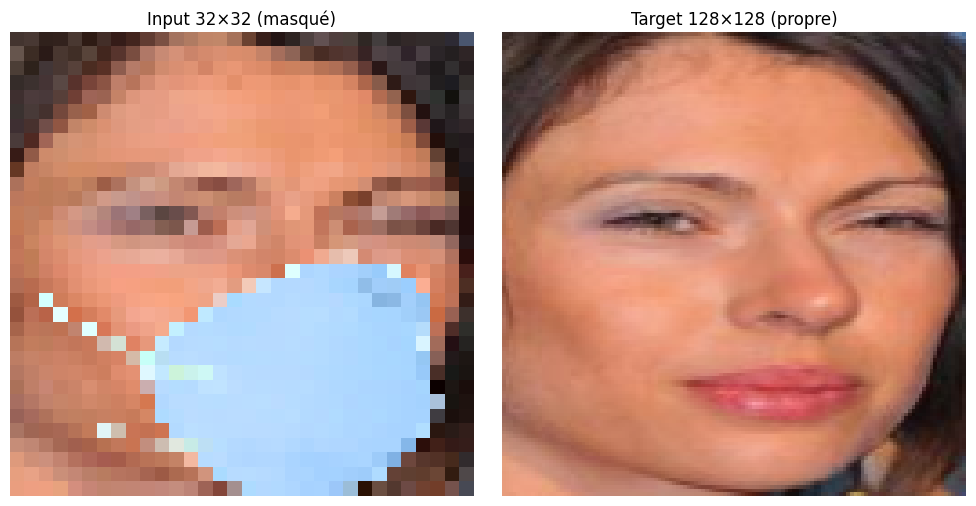


✅ Test réussi !

📊 RÉSUMÉ SETUP
✅ GPU : Activé
✅ PyTorch : 2.10.0+cu128
✅ Dataset : 19742 paires train
✅ Packages : opencv, lpips, timm, torchmetrics

🎯 Prêt pour l'implémentation !


In [3]:
"""
SETUP ENVIRONNEMENT - Vérifications et installations
"""

print("="*60)
print("SETUP ENVIRONNEMENT KAGGLE")
print("="*60)

# ============================================
# 1. VÉRIFIER GPU
# ============================================
print("\n🔍 Vérification GPU...")
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version : {torch.version.cuda}")
    print(f"GPU name : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("✅ GPU activé !")
else:
    print("❌ GPU non disponible")
    print("→ Aller dans Settings → Accelerator → GPU P100")

# ============================================
# 2. INSTALLER PACKAGES
# ============================================
print("\n📦 Installation des packages...")

!pip install -q opencv-python-headless
!pip install -q lpips  # Pour métrique perceptuelle
!pip install -q timm   # Pour certains backbones
!pip install -q torchmetrics  # Pour PSNR, SSIM

print("✅ Packages installés")

# ============================================
# 3. IMPORTS DE BASE
# ============================================
print("\n📚 Test des imports...")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import glob
from pathlib import Path

print("✅ Tous les imports fonctionnent")

# ============================================
# 4. VÉRIFIER DATASET
# ============================================
print("\n📁 Vérification du dataset...")

DATASET_PATH = "/kaggle/working/dataset_processed"

train_input_path = f"{DATASET_PATH}/train/input_32"
train_target_path = f"{DATASET_PATH}/train/target_128"

num_train_input = len(glob.glob(f"{train_input_path}/*.png"))
num_train_target = len(glob.glob(f"{train_target_path}/*.png"))

print(f"Train inputs  : {num_train_input} images")
print(f"Train targets : {num_train_target} images")

if num_train_input == num_train_target and num_train_input > 0:
    print("✅ Dataset prêt !")
else:
    print("❌ Problème avec le dataset")

# ============================================
# 5. TEST CHARGEMENT IMAGE
# ============================================
print("\n🖼️  Test chargement d'une image...")

# Charger une paire
input_img = cv2.imread(f"{train_input_path}/000000.png")
target_img = cv2.imread(f"{train_target_path}/000000.png")

print(f"Input shape  : {input_img.shape}")
print(f"Target shape : {target_img.shape}")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input 32×32 (masqué)")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Target 128×128 (propre)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Test réussi !")

# ============================================
# 6. RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("📊 RÉSUMÉ SETUP")
print("="*60)
print(f"✅ GPU : {'Activé' if torch.cuda.is_available() else 'Non activé'}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ Dataset : {num_train_input} paires train")
print(f"✅ Packages : opencv, lpips, timm, torchmetrics")
print("\n🎯 Prêt pour l'implémentation !")



**verification  que GPU est activé**

In [4]:
import torch

print("="*60)
print("VÉRIFICATION GPU")
print("="*60)

if torch.cuda.is_available():
    print("✅ GPU ACTIVÉ")
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"Mémoire : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU NON ACTIVÉ")
    print("→ Settings → Accelerator → GPU P100")

VÉRIFICATION GPU
✅ GPU ACTIVÉ
GPU : Tesla T4
Mémoire : 15.64 GB


**DATALOADER PYTORCH - MEFSR-GANPour charger les paires 32×32 → 128×128**

In [5]:
%%writefile /kaggle/working/create_dataloader.py
"""
DATALOADER PYTORCH - MEFSR-GAN v4.2
Normalisation [-1, 1] pour WGAN-GP.
Augmentations : flip horizontal uniquement (visages).
"""
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pathlib import Path
import glob
import random

class FaceSRDataset(Dataset):
    def __init__(self, data_root, train=True):
        self.data_root = Path(data_root)
        self.train = train
        self.input_files  = sorted(glob.glob(str(self.data_root / "input_32"   / "*.png")))
        self.target_files = sorted(glob.glob(str(self.data_root / "target_128" / "*.png")))
        assert len(self.input_files) == len(self.target_files), \
            f"Mismatch: {len(self.input_files)} inputs vs {len(self.target_files)} targets"
        print(f"[Dataset] {'Train' if train else 'Val/Test'} — {len(self.input_files)} paires")

    def __len__(self):
        return len(self.input_files)

    def _augment(self, inp, tgt):
        # Flip horizontal seulement (p=0.5)
        if random.random() > 0.5:
            inp = torch.flip(inp, dims=[2])
            tgt = torch.flip(tgt, dims=[2])
        # Pas de jitter de luminosité/contraste pour conserver la plage [-1,1]
        return inp, tgt

    def __getitem__(self, idx):
        input_img  = cv2.imread(self.input_files[idx])
        target_img = cv2.imread(self.target_files[idx])
        input_img  = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)

        # Normalisation [-1, 1]
        input_img  = (input_img.astype(np.float32) / 127.5) - 1.0
        target_img = (target_img.astype(np.float32) / 127.5) - 1.0

        input_tensor  = torch.from_numpy(input_img).permute(2, 0, 1)
        target_tensor = torch.from_numpy(target_img).permute(2, 0, 1)

        if self.train:
            input_tensor, target_tensor = self._augment(input_tensor, target_tensor)

        # Pas de masque binaire ici (vous pouvez en ajouter un si nécessaire)
        return input_tensor, target_tensor

def create_dataloaders(dataset_root, batch_size=16, num_workers=2):
    train_root = Path(dataset_root) / "train"
    val_root   = Path(dataset_root) / "val"
    test_root  = Path(dataset_root) / "test"

    train_dataset = FaceSRDataset(train_root, train=True)
    val_dataset   = FaceSRDataset(val_root,   train=False)
    test_dataset  = FaceSRDataset(test_root,  train=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  num_workers=num_workers,
                              pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                              shuffle=False, num_workers=num_workers,
                              pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False, num_workers=num_workers,
                              pin_memory=True)

    print(f"[DataLoader] Train={len(train_dataset)} | Val={len(val_dataset)} | Test={len(test_dataset)}")
    return train_loader, val_loader, test_loader

Writing /kaggle/working/create_dataloader.py


1. **MODULE 1 : MASK REMOVAL**

In [6]:
%%writefile /kaggle/working/module1_mask_removal.py
"""
MODULE 1 : MASK REMOVAL
Inspiré de JDSR-GAN (2023)
IDENTIQUE pour toutes les versions

Input : [B, 3, 32, 32] (visage masqué LR)
Output : [B, 64, 32, 32] (features débruitées)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    """Bloc résiduel de base avec skip connection"""
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual  # Skip connection
        out = self.relu(out)
        return out


class MaskRemovalModule(nn.Module):
    """
    Module de débruitage pour enlever le masque facial
    """
    
    def __init__(self, in_channels=3, out_channels=64, num_residual_blocks=4):
        super(MaskRemovalModule, self).__init__()
        
        # Encoder
        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Résidual blocks
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(64) for _ in range(num_residual_blocks)
        ])
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        features = self.initial_conv(x)
        for res_block in self.residual_blocks:
            features = res_block(features)
        features = self.decoder(features)
        return features

Writing /kaggle/working/module1_mask_removal.py


**2. MODULE 2 : EDGE FUSION + attention**

In [7]:
%%writefile /kaggle/working/module2_edge_fusion.py
"""
MODULE 2 : EDGE FUSION AVEC ATTENTION
Inspiré de Cheng EFBPGAN (2024)

Input : [B, 64, 32, 32] features + [B, 1, 32, 32] edges
Output : [B, 64, 32, 32] features enrichies
"""

import torch
import torch.nn as nn
import cv2
import numpy as np


# ============================================
# EXTRACTION EDGES (CANNY) - CORRIGÉ
# ============================================
def extract_edges_canny(images, low_threshold=50, high_threshold=150):
    """
    Extrait les contours via Canny
    images: [B, 3, H, W] normalisées en [-1, 1]
    return: [B, 1, H, W] dans [0, 1]
    """
    batch_size, _, H, W = images.shape
    device = images.device

    edges_batch = []

    for i in range(batch_size):
        # to CPU
        img = images[i].detach().cpu().permute(1, 2, 0).numpy()

        # ============================================
        # CORRECTION NORMALISATION [-1,1] → [0,255]
        # ============================================
        img = ((img + 1.0) / 2.0) * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)

        # RGB → Gray
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Canny edges
        edges = cv2.Canny(gray, low_threshold, high_threshold)

        # [0,255] → [0,1]
        edges = edges.astype(np.float32) / 255.0

        edges_batch.append(edges)

    edges_batch = np.stack(edges_batch, axis=0)
    edges_tensor = torch.from_numpy(edges_batch).unsqueeze(1)

    return edges_tensor.to(device)


# ============================================
# ATTENTION MODULES
# ============================================
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2, 1, kernel_size,
            padding=kernel_size // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)

        return self.sigmoid(x)


class EdgeFusionAttention(nn.Module):
    """
    Fusion features + edges avec attention (CBAM-like)
    """

    def __init__(self, feature_channels=64):
        super().__init__()

        self.channel_attn = ChannelAttention(feature_channels)
        self.spatial_attn = SpatialAttention()

        self.fusion = nn.Sequential(
            nn.Conv2d(feature_channels + 1, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(feature_channels, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, features, edges):
        """
        features: [B, 64, 32, 32]
        edges:    [B, 1, 32, 32]
        """

        # Channel attention
        ca = self.channel_attn(features)
        features = features * ca

        # Spatial attention guidée par edges
        sa = self.spatial_attn(edges)
        features = features * sa

        # Fusion
        x = torch.cat([features, edges], dim=1)  # [B,65,H,W]
        x = self.fusion(x)

        return x

Writing /kaggle/working/module2_edge_fusion.py


3. **MODULE 3 : SR NETWORK AVEC ESRGAN**

In [8]:
%%writefile /kaggle/working/module3_sr_network.py
"""
MODULE 3 : SR NETWORK AVEC ESRGAN
Architecture RRDB (Residual in Residual Dense Block)

Input : [B, 64, 32, 32]
Output : [B, 3, 128, 128] (facteur ×4)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================
# UPSAMPLING BLOCK
# ============================================
class UpsampleBlock(nn.Module):
    """Upsampling block (×2) avec PixelShuffle"""
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.prelu = nn.PReLU()
    
    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.prelu(x)
        return x


# ============================================
# ESRGAN RRDB BLOCKS
# ============================================
class DenseBlock(nn.Module):
    """Dense block pour RRDB"""
    def __init__(self, channels, growth_channels=32):
        super(DenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, growth_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3*growth_channels, growth_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4*growth_channels, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.beta = 0.2  # Résidual scaling
    
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], dim=1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], dim=1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], dim=1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], dim=1))
        return x5 * self.beta + x


class RRDB(nn.Module):
    """Residual in Residual Dense Block"""
    def __init__(self, channels, growth_channels=32):
        super(RRDB, self).__init__()
        self.dense1 = DenseBlock(channels, growth_channels)
        self.dense2 = DenseBlock(channels, growth_channels)
        self.dense3 = DenseBlock(channels, growth_channels)
        self.beta = 0.2
    
    def forward(self, x):
        out = self.dense1(x)
        out = self.dense2(out)
        out = self.dense3(out)
        return out * self.beta + x


class SRNetworkESRGAN(nn.Module):
    """
    Version 2.0 : SR Network avec RRDB (ESRGAN)
    Plus puissant que ResNet simple
    """
    
    def __init__(self, in_channels=64, out_channels=3, num_rrdb_blocks=12):
        super(SRNetworkESRGAN, self).__init__()
        
        # Initial conv
        self.conv_first = nn.Conv2d(in_channels, 64, 3, padding=1)
        
        # RRDB blocks
        self.rrdb_blocks = nn.ModuleList([
            RRDB(64, growth_channels=32) for _ in range(num_rrdb_blocks)
        ])
        
        # Conv après RRDB
        self.conv_body = nn.Conv2d(64, 64, 3, padding=1)
        
        # Upsampling ×4 (2 blocs ×2)
        self.upsample1 = UpsampleBlock(64, scale_factor=2)  # 32 → 64
        self.upsample2 = UpsampleBlock(64, scale_factor=2)  # 64 → 128
        
        # Conv finale
        self.conv_hr = nn.Conv2d(64, 64, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.conv_last = nn.Conv2d(64, out_channels, 3, padding=1)
    
    def forward(self, x):
        """
        Args:
            x : [B, 64, 32, 32] features enrichies
        
        Returns:
            out : [B, 3, 128, 128] image HR
        """
        feat = self.conv_first(x)
        trunk = feat
        
        # RRDB processing
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        
        trunk = self.conv_body(trunk)
        feat = feat + trunk  # Long skip connection
        
        # Upsampling
        feat = self.upsample1(feat)  # [B, 64, 64, 64]
        feat = self.upsample2(feat)  # [B, 64, 128, 128]
        
        # Output RGB
        out = self.conv_hr(feat)
        out = self.lrelu(out)
        out = self.conv_last(out)  # [B, 3, 128, 128]
        
        return out

Writing /kaggle/working/module3_sr_network.py


**4. MEFSR-GAN VERSION**

In [9]:
%%writefile /kaggle/working/mefsr_gan_v2.py
"""
MEFSR-GAN VERSION 2.0
Architecture avec attention et ESRGAN

INPUT : [B, 3, 32, 32] visage masqué LR
OUTPUT : [B, 3, 128, 128] visage propre HR

Modules :
1. Mask Removal (identique à v1)
2. Edge Fusion avec Attention (Channel + Spatial)
3. SR Network ESRGAN (RRDB)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

# Import des modules
import sys
sys.path.append('/kaggle/working/')

from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN


class MEFSR_GAN_v2(nn.Module):
    """
    MEFSR-GAN Version 2.0
    - Fusion avec attention (channel + spatial)
    - Super-résolution ESRGAN (RRDB)
    """
    
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=8):
        super(MEFSR_GAN_v2, self).__init__()
        
        # Module 1 : Mask Removal (identique)
        self.mask_removal = MaskRemovalModule(
            in_channels=3,
            out_channels=64,
            num_residual_blocks=num_mask_blocks
        )
        
        # Module 2 : Edge Fusion avec Attention
        self.edge_fusion = EdgeFusionAttention(
            feature_channels=64
        )
        
        # Module 3 : SR Network ESRGAN
        self.sr_network = SRNetworkESRGAN(
            in_channels=64,
            out_channels=3,
            num_rrdb_blocks=num_rrdb_blocks
        )
    
    def forward(self, x):
        """
        Forward pass complet
        
        Args:
            x : [B, 3, 32, 32] visage masqué LR
        
        Returns:
            output : [B, 3, 128, 128] visage propre HR
        """
        # Module 1 : Enlever masque
        features = self.mask_removal(x)  # [B, 64, 32, 32]
        
        # Module 2a : Extraire edges
        with torch.no_grad():
            edges = extract_edges_canny(x)  # [B, 1, 32, 32]
        
        # Module 2b : Fusion features + edges avec attention
        fused_features = self.edge_fusion(features, edges)  # [B, 64, 32, 32]
        
        # Module 3 : Super-résolution ESRGAN
        output = self.sr_network(fused_features)  # [B, 3, 128, 128]
        
        return output
    
    def get_features(self, x):
        """
        Récupérer les features intermédiaires (utile pour visualisation)
        """
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(features, edges)
        return {
            'mask_removed_features': features,
            'edges': edges,
            'fused_features': fused
        }


# ============================================
# TEST DE L'ARCHITECTURE COMPLÈTE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST ARCHITECTURE COMPLÈTE : MEFSR-GAN v2.0")
    print("="*60)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    # Créer le modèle
    model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=8).to(device)
    
    # Compter paramètres
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nNombre total de paramètres : {total_params:,}")
    
    # Détail par module
    module1_params = sum(p.numel() for p in model.mask_removal.parameters())
    module2_params = sum(p.numel() for p in model.edge_fusion.parameters())
    module3_params = sum(p.numel() for p in model.sr_network.parameters())
    
    print(f"\nDétail :")
    print(f"  Module 1 (Mask Removal) : {module1_params:,}")
    print(f"  Module 2 (Edge Fusion)  : {module2_params:,}")
    print(f"  Module 3 (SR Network)   : {module3_params:,}")
    
    # Test forward pass
    print(f"\n{'='*60}")
    print("TEST FORWARD PASS")
    print("="*60)
    
    batch_size = 4
    x = torch.randn(batch_size, 3, 32, 32).to(device)
    
    print(f"\nInput shape : {x.shape}")
    
    with torch.no_grad():
        output = model(x)
    
    print(f"Output shape : {output.shape}")
    
    # Vérifier dimensions
    assert output.shape == (batch_size, 3, 128, 128), "Dimensions incorrectes !"
    
    print("\n✅ Architecture complète fonctionne !")
    
    # Vérifier range de sortie
    print(f"\nOutput range : [{output.min():.3f}, {output.max():.3f}]")
    
    # Mémoire GPU
    if torch.cuda.is_available():
        memory = torch.cuda.memory_allocated(device) / 1e9
        print(f"GPU memory used : {memory:.2f} GB")
    
    # Test avec DataLoader (si disponible)
    print(f"\n{'='*60}")
    print("TEST AVEC DATALOADER (optionnel)")
    print("="*60)
    
    try:
        # Essayer de charger le DataLoader
        import sys
        sys.path.append('/kaggle/working')
        from create_dataloader import create_dataloaders
        
        train_loader, _, _ = create_dataloaders(
            "/kaggle/working/dataset_processed",
            batch_size=4
        )
        
        # Tester sur un vrai batch
        inputs, targets = next(iter(train_loader))
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        print(f"\nReal batch :")
        print(f"  Inputs : {inputs.shape}")
        print(f"  Targets : {targets.shape}")
        
        with torch.no_grad():
            outputs = model(inputs)
        
        print(f"  Outputs : {outputs.shape}")
        print("\n✅ Test avec vraies données : OK !")
        
    except Exception as e:
        print(f"\n⚠️  DataLoader non disponible : {e}")
        print("   (Normal si pas encore sur Kaggle)")
    
    print("\n" + "="*60)
    print("✅ MEFSR-GAN v2.0 PRÊT POUR L'ENTRAÎNEMENT !")
    print("="*60)

Writing /kaggle/working/mefsr_gan_v2.py


In [10]:
%%writefile /kaggle/working/module_losses.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_msssim import SSIM

# ============================================================
# PERCEPTUAL LOSS (VGG16) — adapté à [-1,1]
# ============================================================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg

        # Normalisation ImageNet (pour entrée [0,1])
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, sr, hr):
        # sr, hr dans [-1,1] → les ramener dans [0,1]
        sr_01 = (sr + 1) / 2.0
        hr_01 = (hr + 1) / 2.0
        sr_norm = (sr_01 - self.mean) / self.std
        hr_norm = (hr_01 - self.mean) / self.std
        return F.l1_loss(self.vgg(sr_norm), self.vgg(hr_norm))

# ============================================================
# IDENTITY LOSS (FaceNet) — adapté à [-1,1]
# ============================================================
class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super().__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet_device = torch.device('cpu')
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(self.facenet_device)
        for p in self.facenet.parameters():
            p.requires_grad = False
        self.main_device = torch.device(device) if isinstance(device, str) else device

    def forward(self, sr, hr):
        # sr, hr dans [-1,1] → [0,1]
        sr_01 = (sr + 1) / 2.0
        hr_01 = (hr + 1) / 2.0
        sr_resized = F.interpolate(sr_01, (160, 160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr_01, (160, 160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized.to(self.facenet_device))
        hr_emb = self.facenet(hr_resized.to(self.facenet_device))
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean().to(self.main_device)

# ============================================================
# SSIM LOSS — adapté à [-1,1] (data_range=2.0)
# ============================================================
class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super().__init__()
        self.ssim = SSIM(data_range=2.0, size_average=True, channel=channel)

    def forward(self, img1, img2):
        # img1, img2 dans [-1,1] (data_range=2.0)
        return 1 - self.ssim(img1, img2)

# ============================================================
# PIXEL LOSS — adapté à [-1,1] (MAE + MSE)
# ============================================================
def pixel_loss_fn(pred, target, mae_fn, mse_fn):
    # pred, target dans [-1,1]
    return 0.8 * mae_fn(pred, target) + 0.2 * mse_fn(pred, target)

Writing /kaggle/working/module_losses.py


**losses** :  Pixel Loss, Perceptual, Identity  

**installation et test**

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        # Charger VGG16 pré-entraîné et garder seulement les premières couches (jusqu'à la couche 16)
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        # sr et hr doivent être dans l'intervalle [0,1] ou normalisés comme pour VGG
        # VGG attend des images normalisées avec mean et std, mais on peut passer directement
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

In [12]:
# Test rapide
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_loss = VGGPerceptualLoss().to(device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = vgg_loss(x, y)
print(f"Perceptual loss test: {loss.item()}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 222MB/s] 


Perceptual loss test: 0.8565136194229126


In [13]:
!pip uninstall -y numpy scipy facenet-pytorch
!pip install numpy==1.26.4 scipy==1.13.1
!pip install facenet-pytorch

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 52.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 wh

In [14]:
import numpy, scipy, facenet_pytorch, torch
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("✅ facenet-pytorch OK")
# Test de conversion numpy
x = torch.randn(1, 3, 32, 32)
y = x.cpu().numpy()
print("✅ Conversion numpy réussie")

numpy: 2.0.2
scipy: 1.13.1
✅ facenet-pytorch OK
✅ Conversion numpy réussie


In [15]:
from facenet_pytorch import InceptionResnetV1
import torch.nn as nn
import torch.nn.functional as F

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet_device = torch.device('cpu')  # ← FaceNet toujours sur CPU
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(self.facenet_device)
        for param in self.facenet.parameters():
            param.requires_grad = False
        self.main_device = torch.device(device) if isinstance(device, str) else device

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160, 160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160, 160), mode='bilinear', align_corners=False)
        sr_resized = sr_resized.to(self.facenet_device)  # ← CPU pour FaceNet
        hr_resized = hr_resized.to(self.facenet_device)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean().to(self.main_device)  # ← retour sur GPU


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id_loss = IdentityLoss(device=device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = id_loss(x, y)
print(f"Identity loss test: {loss.item()}")


  0%|          | 0.00/107M [00:00<?, ?B/s]

Identity loss test: 0.04018405079841614


In [17]:
!pip install pytorch-msssim

In [18]:
import torch.nn as nn
from pytorch_msssim import SSIM

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=255.0, size_average=True, channel=channel)
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

In [19]:

!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0

In [20]:
import numpy
print("NumPy version :", numpy.__version__)

NumPy version : 2.0.2


**code d'entrainement**

In [21]:
!pip install --force-reinstall numpy scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 83.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 56.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.6 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have num

In [22]:
import shutil
import os

source = "/kaggle/input/datasets/fridamag/mefsr-v4-3-final-epoch70"
destination = "/kaggle/working/"

# Vérifier que le dossier source existe
if not os.path.exists(source):
    raise FileNotFoundError(f"Le dossier source n'existe pas : {source}")

# Créer le dossier destination s'il n'existe pas
os.makedirs(destination, exist_ok=True)

# Copier récursivement tout le contenu (fichiers et sous-dossiers)
# dirs_exist_ok=True permet de fusionner avec ce qui existe déjà dans working
shutil.copytree(source, destination, dirs_exist_ok=True)

print(f"Copie terminée : {source} → {destination}")

Copie terminée : /kaggle/input/datasets/fridamag/mefsr-v4-3-final-epoch70 → /kaggle/working/


In [23]:
"""
╔══════════════════════════════════════════════════════════════╗
║     MEFSR-GAN v4.3_FINAL — EPOCHS 70→80 (DERNIÈRE LIGNE)    ║
║                                                              ║
║  2 CHANGEMENTS vs epochs 58-70 :                            ║
║                                                              ║
║  1. LAMBDA_ADV  0.0003 → 0.0005                             ║
║     → légère netteté supplémentaire sur les contours         ║
║     → ADV reste faible donc PSNR préservé                   ║
║                                                              ║
║  2. LAMBDA_PIXEL 1.2 → 1.5                                  ║
║     → supervision pixel encore plus forte                    ║
║     → output colle encore plus au target                     ║
║                                                              ║
║  Tout le reste identique à v4.3_FINAL                       ║
╚══════════════════════════════════════════════════════════════╝
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import os, time, csv, shutil, json, subprocess
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pytorch_msssim import SSIM as MSSSIM
import cv2

import sys
sys.path.append('/kaggle/working/')

from create_dataloader    import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion  import EdgeFusionAttention
from module3_sr_network   import SRNetworkESRGAN
from module_losses        import VGGPerceptualLoss, IdentityLoss, SSIMLoss, pixel_loss_fn

torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — OPTIMISÉE POUR DUAL OBJECTIF              ║
# ╚══════════════════════════════════════════════════════════════╝
VERSION           = "v4.3_FINAL"
EPOCHS            = 80
BATCH_SIZE        = 16
DATASET_ROOT      = "/kaggle/working/dataset_processed"
GRAD_CLIP         = 1.0
VALIDATION_EVERY  = 5
IDENTITY_EVERY    = 2
MAX_SESSION_HOURS = 11.0
MAX_SESSION_SECS  = MAX_SESSION_HOURS * 3600

LR_G      = 5e-5   # ← réduit pour fine-tuning (était 1e-4)
LR_D      = 1e-4
N_CRITIC  = 2      # ← réduit de 3→2 : G reçoit plus de steps
LAMBDA_GP = 25

# ── Lambdas rééquilibrés ────────────────────────────────────────
LAMBDA_PIXEL  = 1.5   # ← 1.2→1.5 : encore plus fidèle au target
LAMBDA_SSIM   = 0.6   # ← 0.4→0.6 : structure/couleurs fidèles
LAMBDA_PERCEP = 0.2   # ← 0.4→0.2 : réduit (hallucine des textures)
LAMBDA_ID     = 0.2   # ← 0.3→0.2 : réduit légèrement
LAMBDA_ADV    = 5e-4  # ← 3e-4→5e-4 : légère netteté supplémentaire

KAGGLE_USERNAME = "arabimag"
PREV_VERSION    = "v4.2_WGANGP_stable"   # pour charger le checkpoint
DATASET_SLUG    = f"{KAGGLE_USERNAME}/mefsr-{VERSION.lower().replace('_','-')}"
CHECKPOINT_DIR  = f"/kaggle/working/checkpoints_{VERSION}"
PREV_CKPT_DIR   = f"/kaggle/working/checkpoints_{PREV_VERSION}"
VISUAL_DIR      = f"/kaggle/working/visuals_{VERSION}"
LOG_FILE        = f"/kaggle/working/log_{VERSION}.csv"
METRICS_FILE    = f"/kaggle/working/metrics_{VERSION}.txt"
LOCAL_CKPT      = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
PREV_CKPT       = os.path.join(PREV_CKPT_DIR,  "latest_checkpoint.pth")
BEST_MODEL      = os.path.join(CHECKPOINT_DIR, "best_model.pth")
PREV_BEST       = os.path.join(PREV_CKPT_DIR,  "best_model.pth")

# Kaggle INPUT (reprise inter-session)
INPUT_BASE = (f"/kaggle/input/mefsr-{PREV_VERSION.lower().replace('_','-')}/"
              f"checkpoints_{PREV_VERSION}")
INPUT_CKPT = os.path.join(INPUT_BASE, "latest_checkpoint.pth")
INPUT_BEST = os.path.join(INPUT_BASE, "best_model.pth")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR,     exist_ok=True)

print(f"{'='*60}")
print(f"Version       : {VERSION}")
print(f"Device        : {DEVICE}")
print(f"LR_G / LR_D   : {LR_G} / {LR_D}")
print(f"N_CRITIC      : {N_CRITIC}")
print(f"LAMBDA_GP     : {LAMBDA_GP}")
print(f"LAMBDA_PIXEL  : {LAMBDA_PIXEL}  (↑↑ 1.2→1.5 fidélité maximale)")
print(f"LAMBDA_SSIM   : {LAMBDA_SSIM}   (inchangé)")
print(f"LAMBDA_PERCEP : {LAMBDA_PERCEP}  (inchangé)")
print(f"LAMBDA_ADV    : {LAMBDA_ADV}  (↑ 3e-4→5e-4 légère netteté)")
print(f"{'='*60}\n")


# ╔══════════════════════════════════════════════════════════════╗
# ║  EXTRACT EDGES — [-1,1]                                     ║
# ╚══════════════════════════════════════════════════════════════╝
def extract_edges_canny(images, low_threshold=50, high_threshold=150):
    batch_size = images.shape[0]
    device = images.device
    edges_batch = []
    for i in range(batch_size):
        img = images[i].detach().cpu().permute(1, 2, 0).numpy()
        img = np.clip(((img + 1.0) / 2.0) * 255.0, 0, 255).astype(np.uint8)
        gray  = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, low_threshold, high_threshold)
        edges = edges.astype(np.float32) / 255.0
        edges_batch.append(edges)
    edges_arr = np.stack(edges_batch, axis=0)
    return torch.from_numpy(edges_arr).unsqueeze(1).to(device)


# ╔══════════════════════════════════════════════════════════════╗
# ║  MODÈLES                                                    ║
# ╚══════════════════════════════════════════════════════════════╝
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=8):
        super().__init__()
        self.mask_removal = MaskRemovalModule(3, 64, num_mask_blocks)
        self.edge_fusion  = EdgeFusionAttention(feature_channels=64)
        self.sr_network   = SRNetworkESRGAN(64, 3, num_rrdb_blocks)
    def forward(self, x):
        feat  = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(feat, edges)
        return self.sr_network(fused)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, use_norm=True):
            layers = [nn.Conv2d(ic, oc, 4, 2, 1, bias=not use_norm)]
            if use_norm:
                layers.append(nn.InstanceNorm2d(oc, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.net = nn.Sequential(
            *blk(3,   64,  use_norm=False),
            *blk(64,  128, use_norm=True),
            *blk(128, 256, use_norm=True),
            *blk(256, 512, use_norm=True),
            nn.Conv2d(512, 1, 4, 1, 1)
        )
    def forward(self, x):
        return self.net(x).mean(dim=[1, 2, 3])


generator     = MEFSR_GAN_v2().to(DEVICE)
discriminator = Discriminator().to(DEVICE)
print(f"Generator     : {sum(p.numel() for p in generator.parameters()):,} paramètres")
print(f"Discriminator : {sum(p.numel() for p in discriminator.parameters()):,} paramètres\n")


# ╔══════════════════════════════════════════════════════════════╗
# ║  LOSSES                                                     ║
# ╚══════════════════════════════════════════════════════════════╝
mae_loss        = nn.L1Loss()
mse_loss        = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss   = IdentityLoss(device=DEVICE)
ssim_loss       = SSIMLoss(channel=3).to(DEVICE)


# ╔══════════════════════════════════════════════════════════════╗
# ║  OPTIMISEURS                                                ║
# ╚══════════════════════════════════════════════════════════════╝
opt_g = torch.optim.Adam(generator.parameters(),     lr=LR_G, betas=(0.0, 0.9))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.0, 0.9))
sch_g = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_g, 'min', factor=0.5, patience=6, min_lr=1e-6)
sch_d = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_d, 'min', factor=0.5, patience=6, min_lr=1e-6)


# ╔══════════════════════════════════════════════════════════════╗
# ║  GRADIENT PENALTY                                           ║
# ╚══════════════════════════════════════════════════════════════╝
def gradient_penalty(critic, real, fake, device):
    B     = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake.detach()).requires_grad_(True)
    score = critic(interp)
    grads = torch.autograd.grad(
        outputs=score, inputs=interp,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(B, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


# ╔══════════════════════════════════════════════════════════════╗
# ║  REPRISE CHECKPOINT (v4.2 → v4.3)                          ║
# ╚══════════════════════════════════════════════════════════════╝
start_epoch = 0
best_psnr   = 0.0

def load_ckpt(path):
    global start_epoch, best_psnr
    ckpt = torch.load(path, map_location=DEVICE)
    generator.load_state_dict(ckpt['generator'])
    discriminator.load_state_dict(ckpt['discriminator'])
    opt_g.load_state_dict(ckpt['opt_g'])
    opt_d.load_state_dict(ckpt['opt_d'])
    start_epoch = ckpt['epoch'] + 1
    best_psnr   = ckpt.get('best_psnr', 0.0)
    # ✅ Forcer les nouveaux LR (fine-tuning)
    for pg in opt_g.param_groups: pg['lr'] = LR_G
    for pg in opt_d.param_groups: pg['lr'] = LR_D
    print(f"   Epoch {start_epoch} | Best PSNR {best_psnr:.2f} dB")
    print(f"   LR forcé → LR_G={LR_G} | LR_D={LR_D}\n")

if os.path.exists(LOCAL_CKPT):
    print("✅ Reprise checkpoint LOCAL v4.3...")
    load_ckpt(LOCAL_CKPT)
elif os.path.exists(PREV_CKPT):
    print(f"✅ Reprise depuis checkpoint LOCAL {PREV_VERSION}...")
    load_ckpt(PREV_CKPT)
    if os.path.exists(PREV_BEST):
        shutil.copy(PREV_BEST, BEST_MODEL)
elif os.path.exists(INPUT_CKPT):
    print(f"✅ Reprise depuis Kaggle INPUT {PREV_VERSION}...")
    os.makedirs(os.path.dirname(LOCAL_CKPT), exist_ok=True)
    shutil.copy(INPUT_CKPT, LOCAL_CKPT)
    if os.path.exists(INPUT_BEST):
        shutil.copy(INPUT_BEST, BEST_MODEL)
    load_ckpt(LOCAL_CKPT)
else:
    print("🆕 Démarrage from scratch\n")


# ╔══════════════════════════════════════════════════════════════╗
# ║  MÉTRIQUES pour [-1,1]                                      ║
# ╚══════════════════════════════════════════════════════════════╝
ssim_metric = MSSSIM(data_range=2.0, size_average=True, channel=3).to(DEVICE)

def compute_psnr(out, tgt):
    out_01 = (out.clamp(-1, 1) + 1) / 2.0
    tgt_01 = (tgt.clamp(-1, 1) + 1) / 2.0
    mse = torch.mean((out_01 - tgt_01) ** 2, dim=[1, 2, 3])
    return (20 * torch.log10(
        torch.tensor(1.0, device=out.device) / torch.sqrt(mse + 1e-8)
    )).mean().item()

def compute_ssim(out, tgt):
    return ssim_metric(out.clamp(-1, 1), tgt.clamp(-1, 1)).item()


# ╔══════════════════════════════════════════════════════════════╗
# ║  DATALOADERS                                                ║
# ╚══════════════════════════════════════════════════════════════╝
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

val_batch_fixed = None
for batch in val_loader:
    val_batch_fixed = (batch[0][:4].to(DEVICE), batch[1][:4].to(DEVICE))
    break


# ╔══════════════════════════════════════════════════════════════╗
# ║  VISUALISATION                                              ║
# ╚══════════════════════════════════════════════════════════════╝
def to_display(tensor):
    img = tensor.cpu().permute(1, 2, 0).numpy()
    if img.min() < -0.1:
        img = (img + 1.0) / 2.0
    elif img.max() > 2.0:
        img = img / 255.0
    return np.clip(img, 0, 1)

def visualize_results(epoch, gen, val_batch, save_dir):
    try:
        gen.eval()
        inputs, targets = val_batch
        with torch.no_grad():
            outputs = gen(inputs)
        psnr_b = compute_psnr(outputs, targets)
        ssim_b = compute_ssim(outputs, targets)
        fig, axes = plt.subplots(4, 3, figsize=(12, 12))
        fig.suptitle(
            f"MEFSR-GAN {VERSION} — Epoch {epoch+1}\n"
            f"PSNR: {psnr_b:.2f} dB | SSIM: {ssim_b:.4f} | λ_ADV={LAMBDA_ADV}",
            fontsize=11
        )
        for i in range(4):
            in_up = F.interpolate(
                inputs[i:i+1], size=(128, 128),
                mode='bilinear', align_corners=False
            )[0]
            axes[i, 0].imshow(to_display(in_up));      axes[i, 0].set_title("Input LR");  axes[i, 0].axis('off')
            axes[i, 1].imshow(to_display(outputs[i])); axes[i, 1].set_title("Output SR"); axes[i, 1].axis('off')
            axes[i, 2].imshow(to_display(targets[i])); axes[i, 2].set_title("Target HR"); axes[i, 2].axis('off')
        plt.tight_layout()
        plt.savefig(f"{save_dir}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   📸 epoch_{epoch+1:03d}.png | PSNR: {psnr_b:.2f} dB | SSIM: {ssim_b:.4f}")
    except Exception as e:
        print(f"   ⚠️ Erreur visualisation: {e}")
        plt.close('all')


# ╔══════════════════════════════════════════════════════════════╗
# ║  PUSH KAGGLE                                                ║
# ╚══════════════════════════════════════════════════════════════╝
def push_to_kaggle(epoch, label=""):
    print(f"\n   📤 Push Kaggle epoch {epoch} {label}...")
    try:
        vis_target = os.path.join(CHECKPOINT_DIR, "training_visuals")
        if os.path.exists(VISUAL_DIR):
            shutil.copytree(VISUAL_DIR, vis_target, dirs_exist_ok=True)
        for src, name in [(LOG_FILE, "training_log.csv"), (METRICS_FILE, "metrics.txt")]:
            if os.path.exists(src):
                shutil.copy(src, os.path.join(CHECKPOINT_DIR, name))
        meta = os.path.join(CHECKPOINT_DIR, "dataset-metadata.json")
        if not os.path.exists(meta):
            with open(meta, "w") as f:
                json.dump({"title": f"MEFSR {VERSION}",
                           "id": DATASET_SLUG,
                           "licenses": [{"name": "CC0-1.0"}]}, f)
        r = subprocess.run(
            ["kaggle", "datasets", "version", "-p", CHECKPOINT_DIR,
             "-m", f"epoch {epoch} {label}", "--dir-mode", "zip"],
            capture_output=True, text=True, timeout=240
        )
        if r.returncode != 0:
            r2 = subprocess.run(
                ["kaggle", "datasets", "create", "-p", CHECKPOINT_DIR,
                 "-r", "zip", "--dir-mode", "zip"],
                capture_output=True, text=True, timeout=240
            )
            print(f"   {'✅ Dataset créé' if r2.returncode==0 else '⚠️ '+r2.stderr[:100]}")
        else:
            print(f"   ✅ Dataset mis à jour (epoch {epoch})")
    except Exception as e:
        print(f"   ⚠️ Push échoué : {e}")


# ╔══════════════════════════════════════════════════════════════╗
# ║  LOG CSV                                                    ║
# ╚══════════════════════════════════════════════════════════════╝
log_mode = 'a' if (os.path.exists(LOG_FILE) and start_epoch > 0) else 'w'
with open(LOG_FILE, log_mode, newline='') as f:
    if log_mode == 'w':
        csv.writer(f).writerow([
            'epoch', 'loss_g', 'loss_d', 'w_dist', 'loss_adv',
            'loss_pixel', 'val_loss', 'val_psnr', 'val_ssim',
            'lr_g', 'lr_d', 'time_h'
        ])


# ╔══════════════════════════════════════════════════════════════╗
# ║  BOUCLE D'ENTRAÎNEMENT                                      ║
# ╚══════════════════════════════════════════════════════════════╝
print(f"{'='*60}")
print(f"ENTRAÎNEMENT {VERSION} — Epochs {start_epoch+1} → {EPOCHS}")
print(f"Dernière ligne droite : PIXEL 1.2→1.5 | ADV 3e-4→5e-4")
print(f"{'='*60}\n")

session_start = time.time()
last_push     = -1

for epoch in range(start_epoch, EPOCHS):

    elapsed   = time.time() - session_start
    remaining = MAX_SESSION_SECS - elapsed
    time_h    = elapsed / 3600

    if remaining < 3600:
        print(f"\n⏰ TIMEOUT — {remaining/60:.0f} min restantes...")
        push_to_kaggle(epoch, label="FIN_SESSION")
        break

    generator.train()
    discriminator.train()
    total_g = total_d = total_adv = total_pix = 0.0
    steps = 0

    data_iter = iter(train_loader)
    n_g_steps = len(train_loader) // (N_CRITIC + 1)
    loop = tqdm(range(n_g_steps), desc=f"Epoch {epoch+1}/{EPOCHS}")

    for _ in loop:

        # ── N_CRITIC=2 steps Discriminateur ──────────────────
        loss_d_avg = 0.0
        for _ in range(N_CRITIC):
            try:
                inp, tgt = next(data_iter)
            except StopIteration:
                break
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            with torch.no_grad():
                fake = generator(inp)
            opt_d.zero_grad()
            loss_d = (-discriminator(tgt).mean()
                      + discriminator(fake.detach()).mean()
                      + LAMBDA_GP * gradient_penalty(discriminator, tgt, fake, DEVICE))
            loss_d.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), GRAD_CLIP)
            opt_d.step()
            loss_d_avg += loss_d.item()
        loss_d_avg /= N_CRITIC

        # ── 1 step Générateur ─────────────────────────────────
        try:
            inp, tgt = next(data_iter)
        except StopIteration:
            break
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        fake = generator(inp)
        opt_g.zero_grad()

        adv_loss    = -discriminator(fake).mean()
        pix_loss    = pixel_loss_fn(fake, tgt, mae_loss, mse_loss)
        perc_loss   = perceptual_loss(fake, tgt)
        ssim_loss_v = ssim_loss(fake, tgt)
        id_loss     = (identity_loss(fake, tgt)
                       if steps % IDENTITY_EVERY == 0
                       else torch.tensor(0.0, device=DEVICE))

        # ✅ Nouvelle pondération : PIXEL et SSIM dominants
        loss_g = (LAMBDA_PIXEL  * pix_loss    +
                  LAMBDA_SSIM   * ssim_loss_v +
                  LAMBDA_PERCEP * perc_loss   +
                  LAMBDA_ID     * id_loss      +
                  LAMBDA_ADV    * adv_loss)

        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), GRAD_CLIP)
        opt_g.step()

        total_g   += loss_g.item()
        total_d   += loss_d_avg
        total_adv += adv_loss.item()
        total_pix += pix_loss.item()
        steps += 1
        loop.set_postfix(G=f"{loss_g.item():.3f}", D=f"{loss_d_avg:.3f}",
                         W=f"{-loss_d_avg:.2f}", pix=f"{pix_loss.item():.4f}")

    if steps == 0:
        continue

    avg_g   = total_g / steps
    avg_d   = total_d / steps
    avg_pix = total_pix / steps
    w_dist  = -avg_d
    lr_g    = opt_g.param_groups[0]['lr']
    lr_d    = opt_d.param_groups[0]['lr']

    print(f"\nEp{epoch+1}/{EPOCHS} | {time_h:.2f}h"
          f" | G:{avg_g:.4f} | W-dist:{w_dist:.2f}"
          f" | Pixel:{avg_pix:.4f} | LR_G:{lr_g:.1e}")

    # ── Validation ───────────────────────────────────────────
    val_loss_log = val_psnr_log = val_ssim_log = None

    if (epoch + 1) % VALIDATION_EVERY == 0:
        generator.eval()
        val_loss = val_psnr = val_ssim = 0.0
        with torch.no_grad():
            for vinp, vtgt in val_loader:
                vinp, vtgt = vinp.to(DEVICE), vtgt.to(DEVICE)
                vout = generator(vinp)
                lp = pixel_loss_fn(vout, vtgt, mae_loss, mse_loss)
                lc = perceptual_loss(vout, vtgt)
                ls = ssim_loss(vout, vtgt)
                li = identity_loss(vout, vtgt)
                val_loss += (LAMBDA_PIXEL*lp + LAMBDA_SSIM*ls +
                             LAMBDA_PERCEP*lc + LAMBDA_ID*li).item()
                val_psnr += compute_psnr(vout, vtgt)
                val_ssim += compute_ssim(vout, vtgt)
        val_loss /= len(val_loader)
        val_psnr /= len(val_loader)
        val_ssim /= len(val_loader)
        val_loss_log, val_psnr_log, val_ssim_log = val_loss, val_psnr, val_ssim

        print(f"\n   ┌─ VALIDATION epoch {epoch+1}")
        print(f"   │  PSNR : {val_psnr:.2f} dB  ({val_psnr/25*100:.1f}% vers 25 dB)")
        print(f"   │  SSIM : {val_ssim:.4f}")
        print(f"   │  Loss : {val_loss:.4f}")

        if val_psnr >= 25.0:
            print(f"   │  🎉 OBJECTIF 25 dB ATTEINT !")
        elif val_psnr >= 24.5:
            print(f"   │  ✅ Très proche ! +{25.0-val_psnr:.2f} dB")
        elif val_psnr >= 24.0:
            print(f"   │  ✅ Bonne progression ! +{25.0-val_psnr:.2f} dB")

        if val_psnr > best_psnr:
            best_psnr = val_psnr
            torch.save(generator.state_dict(), BEST_MODEL)
            print(f"   │  ✅ BEST MODEL ! PSNR={val_psnr:.2f} dB SSIM={val_ssim:.4f}")
        else:
            print(f"   │  Best actuel : {best_psnr:.2f} dB")

        print(f"   └{'─'*42}")

        visualize_results(epoch, generator, val_batch_fixed, VISUAL_DIR)
        sch_g.step(val_loss)
        sch_d.step(val_loss)

        with open(METRICS_FILE, "w") as f:
            f.write(f"Version       : {VERSION}\n")
            f.write(f"Epoch         : {epoch+1}/{EPOCHS}\n")
            f.write(f"Best PSNR     : {best_psnr:.2f} dB\n")
            f.write(f"Val PSNR      : {val_psnr:.2f} dB\n")
            f.write(f"Val SSIM      : {val_ssim:.4f}\n")
            f.write(f"LAMBDA_PIXEL  : {LAMBDA_PIXEL}\n")
            f.write(f"LAMBDA_SSIM   : {LAMBDA_SSIM}\n")
            f.write(f"LAMBDA_ADV    : {LAMBDA_ADV}\n")
            f.write(f"W-dist        : {w_dist:.3f}\n")

    # ── Checkpoint ───────────────────────────────────────────
    torch.save({
        'epoch': epoch, 'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'opt_g': opt_g.state_dict(), 'opt_d': opt_d.state_dict(),
        'best_psnr': best_psnr, 'lambda_gp': LAMBDA_GP,
        'lambda_adv': LAMBDA_ADV, 'version': VERSION,
    }, LOCAL_CKPT)

    if (epoch + 1) % 5 == 0 and epoch != last_push:
        push_to_kaggle(epoch + 1)
        last_push = epoch

    with open(LOG_FILE, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch+1, avg_g, avg_d, w_dist, total_adv/steps, avg_pix,
            val_loss_log or '', val_psnr_log or '', val_ssim_log or '',
            lr_g, lr_d, round(time_h, 2)
        ])


# ╔══════════════════════════════════════════════════════════════╗
# ║  ÉVALUATION FINALE — TEST SET                               ║
# ╚══════════════════════════════════════════════════════════════╝
print(f"\n{'='*60}\nÉVALUATION FINALE — TEST SET\n{'='*60}")
if os.path.exists(BEST_MODEL):
    generator.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
    print(f"✅ Best model chargé (PSNR val: {best_psnr:.2f} dB)")

generator.eval()
psnr_list, ssim_list = [], []
with torch.no_grad():
    for inp, tgt in tqdm(test_loader, desc="Test set"):
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        out = generator(inp)
        for i in range(inp.size(0)):
            psnr_list.append(compute_psnr(out[i:i+1], tgt[i:i+1]))
            ssim_list.append(compute_ssim(out[i:i+1], tgt[i:i+1]))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"\n{'='*60}\nRÉSULTATS FINAUX — {VERSION}\n{'='*60}")
print(f"   PSNR : {psnr_mean:.2f} ± {np.std(psnr_list):.2f} dB")
print(f"   SSIM : {ssim_mean:.4f} ± {np.std(ssim_list):.4f}")
print(f"   N    : {len(psnr_list)} images test")
if psnr_mean >= 25.0:
    print(f"   🎉 OBJECTIF 25 dB ATTEINT !")
else:
    print(f"   → Écart : {25.0 - psnr_mean:.2f} dB")
print(f"{'='*60}")
push_to_kaggle(EPOCHS, label="FINAL")

Version       : v4.3_FINAL
Device        : cuda
LR_G / LR_D   : 5e-05 / 0.0001
N_CRITIC      : 2
LAMBDA_GP     : 25
LAMBDA_PIXEL  : 1.5  (↑↑ 1.2→1.5 fidélité maximale)
LAMBDA_SSIM   : 0.6   (inchangé)
LAMBDA_PERCEP : 0.2  (inchangé)
LAMBDA_ADV    : 0.0005  (↑ 3e-4→5e-4 légère netteté)

Generator     : 6,618,791 paramètres
Discriminator : 2,765,633 paramètres



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Reprise checkpoint LOCAL v4.3...
   Epoch 70 | Best PSNR 24.60 dB
   LR forcé → LR_G=5e-05 | LR_D=0.0001

[Dataset] Train — 19742 paires
[Dataset] Val/Test — 2467 paires
[Dataset] Val/Test — 2469 paires
[DataLoader] Train=19742 | Val=2467 | Test=2469
ENTRAÎNEMENT v4.3_FINAL — Epochs 71 → 80
Dernière ligne droite : PIXEL 1.2→1.5 | ADV 3e-4→5e-4



Epoch 71/80: 100%|██████████| 411/411 [14:32<00:00,  2.12s/it, D=-12.647, G=0.504, W=12.65, pix=0.0640]



Ep71/80 | 0.00h | G:0.4923 | W-dist:13.34 | Pixel:0.0673 | LR_G:5.0e-05


Epoch 72/80: 100%|██████████| 411/411 [14:12<00:00,  2.08s/it, D=-12.776, G=0.500, W=12.78, pix=0.0639]



Ep72/80 | 0.24h | G:0.4933 | W-dist:13.23 | Pixel:0.0675 | LR_G:5.0e-05


Epoch 73/80:  16%|█▌        | 65/411 [02:14<11:58,  2.08s/it, D=-16.188, G=0.546, W=16.19, pix=0.0686]


KeyboardInterrupt: 

In [25]:
import os
import zipfile
from datetime import datetime
from IPython.display import FileLink

# Configuration des dossiers/fichiers à sauvegarder (version v4.3_FINAL)
VERSION = "v4.3_FINAL"
CHECKPOINT_DIR = f"/kaggle/working/checkpoints_{VERSION}"
VISUAL_DIR = f"/kaggle/working/visuals_{VERSION}"
LOG_FILE = f"/kaggle/working/log_{VERSION}.csv"
METRICS_FILE = f"/kaggle/working/metrics_{VERSION}.txt"

# Liste des éléments à inclure (uniquement ceux qui existent)
items_to_zip = []
for item in [CHECKPOINT_DIR, VISUAL_DIR, LOG_FILE, METRICS_FILE]:
    if os.path.exists(item):
        items_to_zip.append(item)
    else:
        print(f"⚠️ {item} n'existe pas, ignoré.")

if not items_to_zip:
    raise FileNotFoundError("Aucun fichier ou dossier trouvé à sauvegarder.")

# Création du nom de l'archive avec timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_name = f"mefsr_{VERSION}_epoch70_{timestamp}.zip"

# Compression
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for item in items_to_zip:
        if os.path.isdir(item):
            for root, dirs, files in os.walk(item):
                for file in files:
                    file_path = os.path.join(root, file)
                    # Préserver la structure des dossiers depuis /kaggle/working
                    arcname = os.path.relpath(file_path, "/kaggle/working")
                    zf.write(file_path, arcname)
        else:
            zf.write(item, arcname=os.path.basename(item))

print(f"✅ Archive créée : {zip_name}")
print(f"📦 Taille : {os.path.getsize(zip_name) / (1024*1024):.2f} Mo")
print("🔗 Cliquez sur le lien ci-dessous pour télécharger l'archive :")
display(FileLink(zip_name))

✅ Archive créée : mefsr_v4.3_FINAL_epoch70_20260521_113742.zip
📦 Taille : 132.00 Mo
🔗 Cliquez sur le lien ci-dessous pour télécharger l'archive :


/kaggle/working/mefsr_v4.3_FINAL_epoch70_20260521_113742.zip